In [3]:
# Import necessary libraries and modules
from Tracer import Trajectory, WindField, Fluctuator

# Creating instances

In [ ]:
# if you want to use the RANS data, make sure to provide the correct path to the nc file
file = '../RANS/nc files/flowdata_2m_cartesian.nc' # example file
wind_rans = WindField(profile='rans', ds=file)

# Or you can use the log profile, which is a simple analytical model for the wind speed as a function of height
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=45)

# Create a trajectory with the given parameters
traj = Trajectory(
    ball_speed=76, 
    launch_angle=13, 
    spin_rate=2500,
    wind=wind
    )

Synthesizing wind field with parameters: z_height=100, direction=45, U_ref=8, z0=0.03, z_ref=10


# Solving trajectories

In [5]:
print("solve status:", traj.is_solved, "\n"+"="*20)

# solve it using the Runge-Kutta or Euler method
traj.solve('euler')
print(traj, "\n"+"="*20)
traj.solve('rk45')
print(traj, "\n"+"="*20)

print("solve status:", traj.is_solved)

solve status: False 
Trajectory(ball_speed=76, launch_angle=13, spin_rate=2500, spin_axis=0) 
V0=[74.05  0.   17.1 ], 
W0=[   0.  -261.8    0. ], 
P0=[0 0 0], 
Final Position=[ 2.681e+02  2.102e+01 -1.600e-01], 
 Time=7.11 s 
Trajectory(ball_speed=76, launch_angle=13, spin_rate=2500, spin_axis=0) 
V0=[74.05  0.   17.1 ], 
W0=[   0.  -261.8    0. ], 
P0=[0 0 0], 
Final Position=[2.6876e+02 2.1030e+01 1.2000e-01], 
 Time=7.11 s 
solve status: True


# Rotate settings

In [6]:
# Either create a new trajectory with the desired orientation, 
rotated_traj = Trajectory(
    ball_speed=76, 
    launch_angle=13, 
    spin_rate=2500,
    wind=wind,
    orientation=45 # here
    )

# Or rotate an existing trajectory NB: this has to be solved again

rotated_traj = traj.rotate(45) # here

In [7]:
print(rotated_traj) # see how the values are equal in x and y from rotation

Trajectory(V0=[52.36 52.36 17.1 ], W0=[ 185.12 -185.12    0.  ], P0=[0 0 0])


# Add fluctuations to the wind

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=8, z0=0.03, z_ref=10


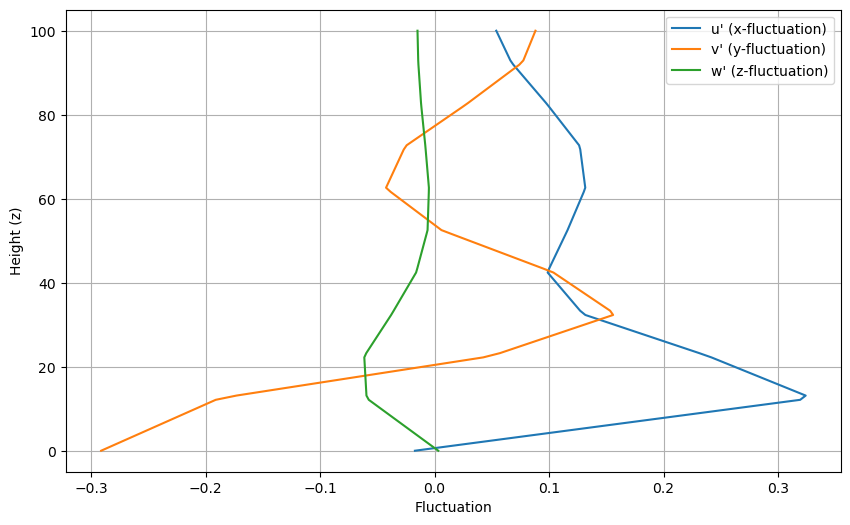

In [12]:
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=0)

methods = ['Simple', 'Langevin', 'POD']
fluc = Fluctuator(method=methods[2], dt=0.01, C0=2.1, cf=1.0, n_modes=10) # settings can be adjusted as needed

traj = Trajectory(
    ball_speed=76, 
    launch_angle=13, 
    spin_rate=2500,
    wind=wind,
    fluc=fluc # include the fluctuator in the trajectory
)

fluc.plot_fluctuation() # visualize the fluctuation to see how it behaves with the chosen method and parameters

# Plot and Animate

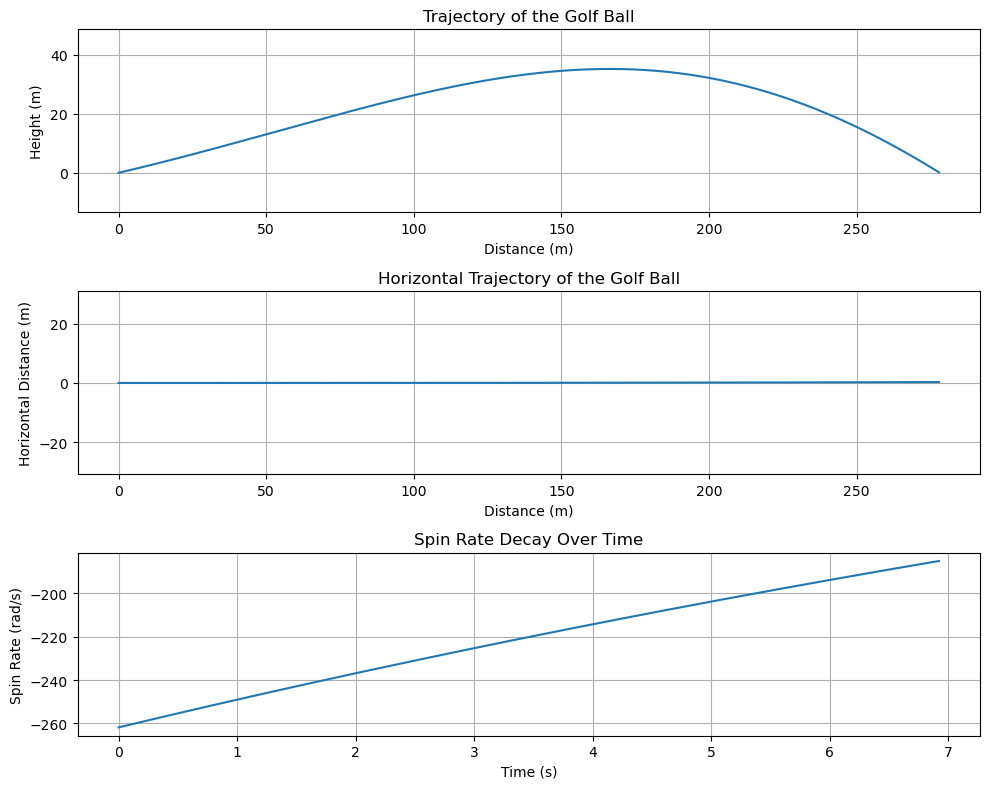

In [16]:
# debug plot of the trajectory
traj.plot()

In [17]:
# Animation of the trajectory to inspect the 3D path and the effect of the spin and wind
rotated_traj.animate()